In [17]:
from ovo import db, schedulers, storage, descriptors, descriptors_refolding, descriptors_rfdiffusion, design_logic, descriptor_logic, project_logic
from ovo import models_rfdiffusion, Threshold
import os
import time
import itertools

from ovo.app.components import molstar_notebook, StructureVisualization
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

%config InlineBackend.figure_format = 'retina'

In [3]:
project, project_round = project_logic.get_or_create_project_round("OVO Publication Examples 1", "Binder design")

In [39]:
for pool in db.Pool.select(round_id=project_round.id):
    print(pool.id, pool.name)

rsj 4ZXB BindCraft default
avz 4ZXB 1000 designs default weights
mmo 4ZXB 1000 designs beta sheet
rwp Top designs diversification


In [40]:
# Pool ids from previous notebooks
POOL_IDS = ['avz', 'mmo']

## Select designs for partial diffusion

In [41]:
values = descriptor_logic.get_wide_descriptor_table(
    design_ids=db.Design.select_values('id', accepted=True, pool_id__in=POOL_IDS),
)
values.head()

,Sequence A,AF2 iPAE,AF2 ipTM score,AF2 pTM score,AF2 Binder PAE,AF2 Binder pLDDT,AF2 Target-aligned Binder RMSD,AlphaFold2 Initial Guess prediction,Radius of gyration (backbone),N binder-target backbone contacts,...,MEC reduced,MEC cystines,Helix-forming residues %,Sheet-forming residues %,Turn-forming residues %,Flexibility average,GRAVY,Instability index,Molecular weight,Sequence entropy
design_id,,,,,,,,,,,,,,,,,,,,,
ovo_avz_0030_cycle02,EEEEKYEKLAEVALYGNELVESIKDEEEKEKLAKYVLEVIENREKI...,5.209966,0.827816,0.900388,4.536248,89.220834,0.821800,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,11.558935,54,...,5960,5960,66.129032,32.258065,11.290323,1.025030,-1.167742,45.725806,7450.1805,2.963865
ovo_avz_0124_cycle04,KEEELEKLAYEYLEYSIKSYEYKKKAEELEKSEYEDEEKKKKEIEE...,5.833490,0.800033,0.887135,5.114184,91.134697,0.827681,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,16.185386,47,...,11920,11920,80.281690,22.535211,5.633803,1.046598,-1.960563,54.145070,8822.7444,2.249319
ovo_avz_0299_cycle01,MSIEEIKKILEEIKKEAEAKNAKKVAEAAAKDPELAKKLAAELTAE...,5.941155,0.804241,0.887639,5.177787,88.795263,0.914129,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,15.665892,65,...,0,0,80.597015,25.373134,7.462687,1.029067,-0.588060,48.489552,7435.4943,2.434554
ovo_avz_0481_cycle03,MEAALKAAEEEKEFQKQVELAKLMIESYKKEGDEEQAEYWEKILEE...,6.987492,0.746239,0.876344,6.214309,85.058039,0.938373,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,13.887859,35,...,8480,8480,74.074074,22.222222,5.555556,1.030087,-1.092593,69.355556,6393.0288,3.018939
ovo_avz_0732_cycle04,EEEEKEKKLKELEKQAKEVEEEGRKKVKEAEAKLKAGDKSEEVKEL...,9.498611,0.558957,0.809674,7.643191,83.656645,0.943637,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,15.913069,49,...,0,0,79.411765,20.588235,8.823529,1.042478,-1.427941,40.220588,7896.9065,2.551309


In [42]:
print(values.columns.to_list())

['Sequence A', 'AF2 iPAE', 'AF2 ipTM score', 'AF2 pTM score', 'AF2 Binder PAE', 'AF2 Binder pLDDT', 'AF2 Target-aligned Binder RMSD', 'AlphaFold2 Initial Guess prediction', 'Radius of gyration (backbone)', 'N binder-target backbone contacts', 'Interface target residues', 'N binder-hotspots backbone contacts', 'N hotspots on interface', 'PyDSSP String', 'PyDSSP Loop %', 'PyDSSP Helix %', 'PyDSSP Beta Sheet %', 'RFdiffusion backbone design', 'RFdiffusion .trb file', 'ProteinMPNN FastRelax sequence design', 'Rosetta ddG', 'Contact molecular surface', 'Spatial aggregation propensity (SAP)', 'Sequence length', 'Ala %', 'Cys %', 'Asp %', 'Glu %', 'Phe %', 'Gly %', 'His %', 'Ile %', 'Lys %', 'Leu %', 'Met %', 'Asn %', 'Pro %', 'Gln %', 'Arg %', 'Ser %', 'Thr %', 'Val %', 'Trp %', 'Tyr %', 'Nonpolar residues %', 'Polar uncharged residues %', 'Positive residues %', 'Negative residues %', 'Turn forming residues %', 'Aromatic residues %', 'DENQ %', 'Aromaticity', 'Charge at pH 5.5', 'Charge at pH

In [43]:
designs = db.Design.select_dataframe(
    pool_id__in=POOL_IDS,
    limit=None,
    accepted=True # Note that we are only selecting designs that pass our default thresholds
)
print(f'{len(designs):,} accepted designs')
designs = designs.join(values)
designs.head()

6 accepted designs


,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence A,AF2 iPAE,AF2 ipTM score,AF2 pTM score,...,MEC reduced,MEC cystines,Helix-forming residues %,Sheet-forming residues %,Turn-forming residues %,Flexibility average,GRAVY,Instability index,Molecular weight,Sequence entropy
id,,,,,,,,,,,,,,,,,,,,,
ovo_avz_0030_cycle02,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,EEEEKYEKLAEVALYGNELVESIKDEEEKEKLAKYVLEVIENREKI...,5.209966,0.827816,0.900388,...,5960,5960,66.129032,32.258065,11.290323,1.025030,-1.167742,45.725806,7450.1805,2.963865
ovo_avz_0124_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,KEEELEKLAYEYLEYSIKSYEYKKKAEELEKSEYEDEEKKKKEIEE...,5.833490,0.800033,0.887135,...,11920,11920,80.281690,22.535211,5.633803,1.046598,-1.960563,54.145070,8822.7444,2.249319
ovo_avz_0299_cycle01,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,MSIEEIKKILEEIKKEAEAKNAKKVAEAAAKDPELAKKLAAELTAE...,5.941155,0.804241,0.887639,...,0,0,80.597015,25.373134,7.462687,1.029067,-0.588060,48.489552,7435.4943,2.434554
ovo_avz_0481_cycle03,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,MEAALKAAEEEKEFQKQVELAKLMIESYKKEGDEEQAEYWEKILEE...,6.987492,0.746239,0.876344,...,8480,8480,74.074074,22.222222,5.555556,1.030087,-1.092593,69.355556,6393.0288,3.018939
ovo_avz_0732_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,EEEEKEKKLKELEKQAKEVEEEGRKKVKEAEAKLKAGDKSEEVKEL...,9.498611,0.558957,0.809674,...,0,0,79.411765,20.588235,8.823529,1.042478,-1.427941,40.220588,7896.9065,2.551309


In [44]:
minimize_columns = ['AF2 iPAE', 'AF2 Target-aligned Binder RMSD', 'Rosetta ddG']
maximize_columns = []

avg_rank = sum([designs[col].fillna(np.inf).rank(method="average") for col in minimize_columns] + \
               [(-designs[col].fillna(-np.inf)).rank(method="average") for col in maximize_columns]) \
                / len(minimize_columns + maximize_columns)
ranked = avg_rank.groupby(designs['pool_id']).apply(pd.Series.sort_values)
ranked

pool_id  id                  
avz      ovo_avz_0030_cycle02    2.000000
         ovo_avz_0124_cycle04    2.000000
         ovo_avz_0299_cycle01    3.666667
         ovo_avz_0481_cycle03    4.000000
         ovo_avz_0732_cycle04    5.666667
mmo      ovo_mmo_0951_cycle02    3.666667
dtype: float64

In [45]:
top_per_group = ranked.groupby(level=0).head(2)
top_per_group

pool_id  id                  
avz      ovo_avz_0030_cycle02    2.000000
         ovo_avz_0124_cycle04    2.000000
mmo      ovo_mmo_0951_cycle02    3.666667
dtype: float64

In [46]:
top_designs = designs.loc[top_per_group.index.get_level_values('id')]
top_designs

,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence A,AF2 iPAE,AF2 ipTM score,AF2 pTM score,...,MEC reduced,MEC cystines,Helix-forming residues %,Sheet-forming residues %,Turn-forming residues %,Flexibility average,GRAVY,Instability index,Molecular weight,Sequence entropy
id,,,,,,,,,,,,,,,,,,,,,
ovo_avz_0030_cycle02,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,EEEEKYEKLAEVALYGNELVESIKDEEEKEKLAKYVLEVIENREKI...,5.209966,0.827816,0.900388,...,5960,5960,66.129032,32.258065,11.290323,1.025030,-1.167742,45.725806,7450.1805,2.963865
ovo_avz_0124_cycle04,avz,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,KEEELEKLAYEYLEYSIKSYEYKKKAEELEKSEYEDEEKKKKEIEE...,5.833490,0.800033,0.887135,...,11920,11920,80.281690,22.535211,5.633803,1.046598,-1.960563,54.145070,8822.7444,2.249319
ovo_mmo_0951_cycle02,mmo,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,MTIPEEILKQLEKLKKLAKESNVFDVEFKIVQNEDGSWSIEVVVKE...,6.621337,0.774178,0.882243,...,5500,5500,50.000000,38.571429,15.714286,1.017940,-0.417143,57.952857,8213.4061,3.146044


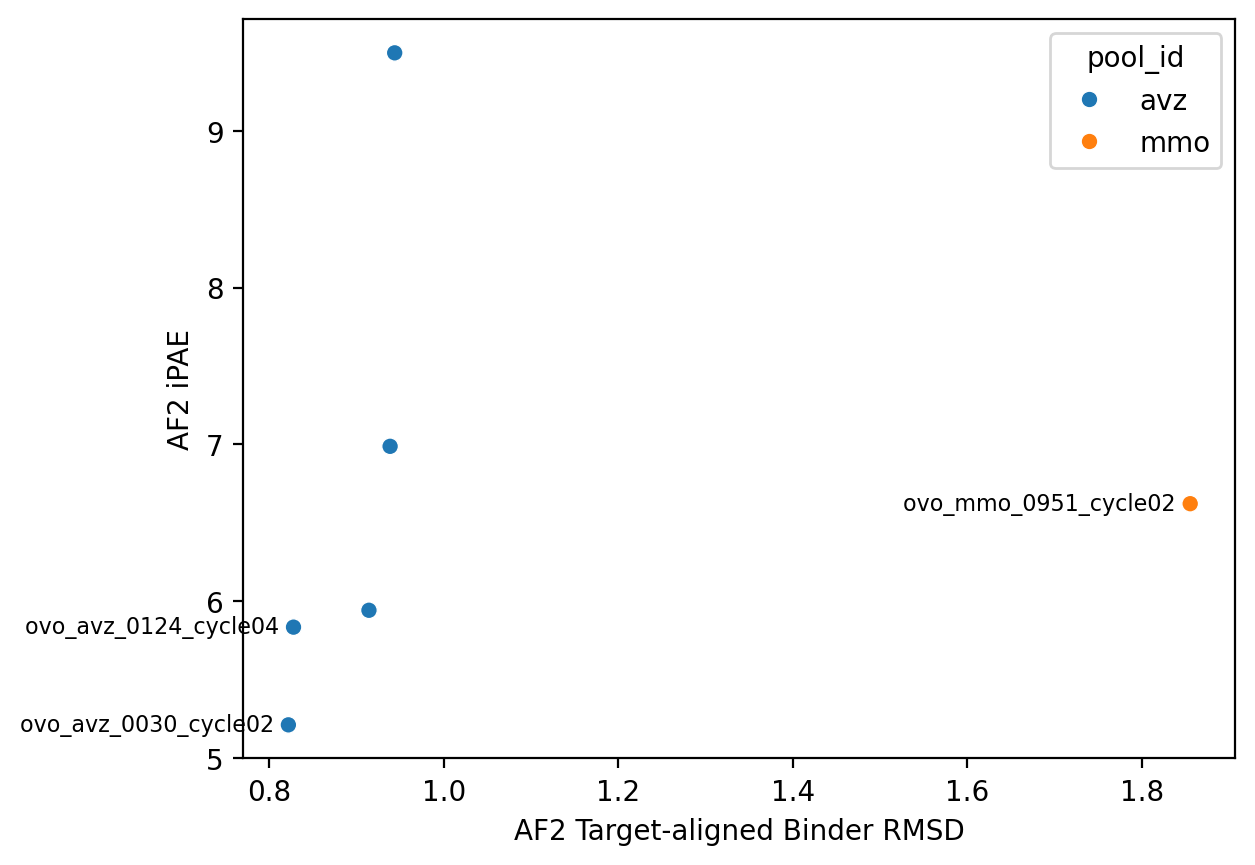

In [47]:
x = 'AF2 Target-aligned Binder RMSD'
y = 'AF2 iPAE'

ax = sns.scatterplot(designs, x=x, y=y, hue='pool_id');
for design_id, design in top_designs.iterrows():
    ax.text(design[x], design[y], design_id + '  ', ha='right', va='center', fontsize=8);

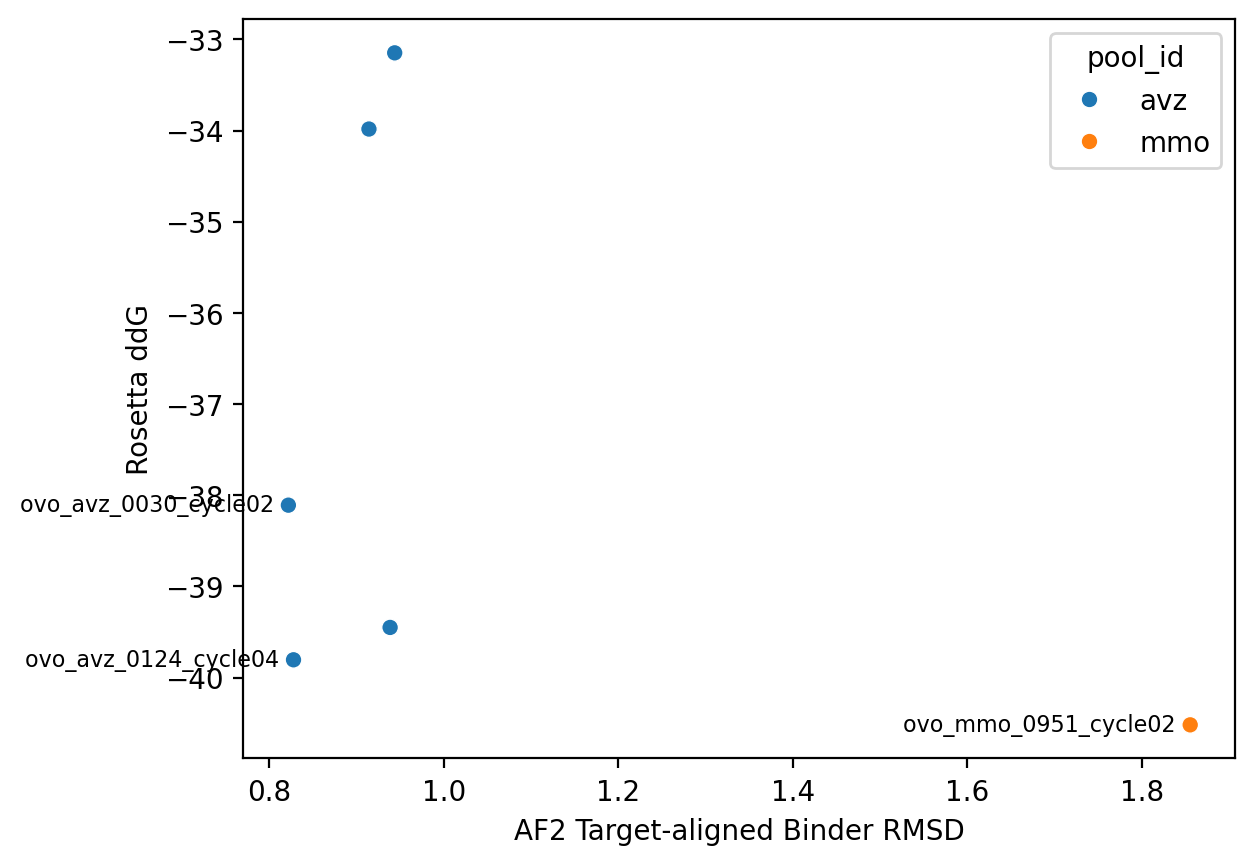

In [48]:
x = 'AF2 Target-aligned Binder RMSD'
y = 'Rosetta ddG'

ax = sns.scatterplot(designs, x=x, y=y, hue='pool_id');
for design_id, design in top_designs.iterrows():
    ax.text(design[x], design[y], design_id + '  ', ha='right', va='center', fontsize=8);

In [49]:
top_designs['Sequence length']

id
ovo_avz_0030_cycle02    62
ovo_avz_0124_cycle04    71
ovo_mmo_0951_cycle02    70
Name: Sequence length, dtype: int64

In [54]:
POOL_NAME = 'Top designs diversification'
POOL_DESCRIPTION = 'Top 2 from each pool by PAE, RMSD and ddG'

workflow = models_rfdiffusion.RFdiffusionBinderDesignWorkflow(
    rfdiffusion_params=models_rfdiffusion.RFdiffusionParams(
        input_pdb_paths=[
            # Note you can use the rfdiffusion backbone, the ProteinMPNN design, or the AF2 design here
            d["structure_path"] for i, d in top_designs.iterrows()
        ],
        contigs=[
            f'{d["Sequence length"]}-{d["Sequence length"]}/0 B6-155' for i, d in top_designs.iterrows()
        ],
        hotspots='B64,B88,B96', # NOTE hotspots need to be with respect to the new structure, so B
        timesteps=20,
        partial_diffusion=True,
        model_weights='Complex_beta',
        num_designs=50,
        batch_size=100, # note that each input will create their own separate batches
    ),
    protein_mpnn_params=models_rfdiffusion.ProteinMPNNParams(
        num_sequences=1,
        fastrelax_cycles=2,
        sampling_temp=0.0001
    ),
    refolding_params=models_rfdiffusion.RefoldingParams(
        primary_test="af2_model_1_multimer_tt_3rec",
    ),
    
)
workflow.validate()
workflow.get_table_row()

Workflow     input                                                                         None
             type                                                     RFdiffusion binder design
RFdiffusion  contigs                           [62-62/0 B6-155, 71-71/0 B6-155, 70-70/0 B6-155]
             hotspots                                                               B64,B88,B96
             model_weights                                                         Complex_beta
             timesteps                                                                       20
             partial_diffusion                                                             True
             num_designs                                                                     50
             cyclic_offset                                                                False
             batch_size                                                                     100
             contigmap_length           

## Submit workflow

In [57]:
print(schedulers.keys())

SCHEDULER_KEY = 'pbs_singularity'

dict_keys(['slurm_singularity', 'pbs_singularity', 'local_singularity', 'local_conda', 'local_single_gpu'])


In [58]:
# SUBMIT new job
design_job, pool = design_logic.submit_design_workflow(
    workflow=workflow,
    pool_name=POOL_NAME,
    pool_description=POOL_DESCRIPTION,
    scheduler_key=SCHEDULER_KEY,
    round_id=project_round.id,
)
print(pool.id)

Submitting workflow: nextflow run -with-trace trace.txt -work-dir /home/username/ovo/workdir/work /home/username/projects/ovo-open-source/ovo/ovo/pipelines/rfdiffusion-end-to-end --publish_dir output --reference_files_dir /home/username/ovo/reference_files --shared_modules ovo:/home/username/projects/ovo-open-source/ovo/ovo,ovo_promb:/home/username/projects/ovo-open-source/ovo-promb/ovo_promb,ovo_proteindj:/home/username/projects/ovo-proteindj/ovo_proteindj -config /home/username/projects/ovo-open-source/ovo/ovo/pipelines/nextflow_default.config -config /home/username/projects/ovo-open-source/ovo/ovo/pipelines/rfdiffusion-end-to-end/nextflow.config -profile singularity -config /home/username/ovo/nextflow_pbs_singularity.config -ansi-log false -bg --batch_size 100 --rfdiffusion_input_pdb /home/username/ovo/workdir/inputs/de/7c35d87cf3faeb79732badb08c23f7d1dc71fa/input_pdb_paths.txt --rfdiffusion_num_designs 50 --rfdiffusion_contig 62-62/0 B6-155,71-71/0 B6-155,70-70/0 B6-155 --rfdiffusi

### Status of current job

In [59]:
design_logic.get_design_jobs_table(id=pool.id)

Pool  \
                                   name   
(Pool, id)                                
qki         Top designs diversification   

                                                            Job               \
                                          description    status     duration   
(Pool, id)                                                                     
qki         Top 2 from each pool by PAE, RMSD and ddG  ⏳Running  Not started   

                    Designs       Workflow                             \
           created accepted total    input                       type   
(Pool, id)                                                              
qki            now     None  None     None  RFdiffusion binder design   

                                                 RFdiffusion  ...  \
                                                     contigs  ...   
(Pool, id)                                                    ...   
qki         [62-62/0 B6-155, 71-71/0 B6-155, 70-70/0 B6-155]  ...   

                    ProteinMPNN                                               \
           num_sequence_designs omit_aa sampling_temp bias_aa run_parameters   
(Pool, id)                                                                     
qki                           2      CX        0.0001                          

                               Refolding              Thresholds  \
                            primary_test esmfold_fp16   AF2 iPAE   
(Pool, id)                                                         
qki         af2_model_1_multimer_tt_3rec        False   ≤ 10.000   

                                                       
           AF2 Target-aligned Binder RMSD Rosetta ddG  
(Pool, id)                                             
qki                               ≤ 5.000   ≤ -20.000  

[1 rows x 31 columns]

## Process job results

Save Design and DescriptorValue objects to database, copy PDB files from workdir into OVO storage.

In [ ]:
# IMPORTANT
# This will "process" the workflow results, which means they will be copied/downloaded from the nextflow working directory
# to the OVO storage directory, and corresponding Design and DescriptorValue objects will be stored in the DB, pointing to the files.

pool = design_logic.process_results(design_job)

Waiting for job 3df2944e-c13e-11f0-9138-029f0fc8e1cf to finish...


In [66]:
db.Design.count(pool_id=pool.id)

450

## Visualize designs and AF2 descriptors

In [69]:
thresholds = {
    descriptors_refolding.AF2_PRIMARY_IPAE.key: Threshold(max_value=10.0),
    descriptors_refolding.AF2_PRIMARY_TARGET_ALIGNED_BINDER_RMSD.key: Threshold(max_value=2.0),
    descriptors_refolding.AF2_PRIMARY_PLDDT_BINDER.key: Threshold(min_value=80.0),
    descriptors_rfdiffusion.PYROSETTA_DDG.key: Threshold(max_value=-30.0),
    #descriptors_rfdiffusion.RADIUS_OF_GYRATION.key: Threshold(max_value=20),
}

In [70]:
values = descriptor_logic.get_wide_descriptor_table(
    design_ids=db.Design.select_values('id', pool_id=pool.id),
    # only select some selected descriptors to save memory
    # you can remove this argument to fetch all available descriptors
    descriptor_keys=thresholds.keys()
)
values.head()

,Sequence A,AF2 iPAE,AF2 Target-aligned Binder RMSD,AF2 Binder pLDDT,Rosetta ddG
design_id,,,,,
ovo_qki_01_01_cycle01,EEEERAERLADLMLRANELAESQESEEDREKLIALAEEILEDEEAL...,5.554042,1.456116,85.392725,-30.095366
ovo_qki_01_01_cycle02,EEEEEGERLAYFMLKANEIANSQEREEDKEAILELALKLLEDEEAL...,8.699325,6.716390,74.132729,-34.324120
ovo_qki_01_01_cycle03,SEAEEGERLAYFMLNANKIALSQKDPEKRQKVLTTALEMYEDKEAR...,7.849532,3.134341,82.036269,-40.546295
ovo_qki_01_02_cycle01,KEREAWEKAYRLWKIAQELAEKAKTEETKEKIAEKAEELIKEFEKL...,19.580656,21.672838,45.581740,-18.781418
ovo_qki_01_02_cycle02,MEEEALEKALELKEIALELAEKAETEEQKKAIEEKAEEIIKDFEGL...,20.732294,12.380045,44.924754,-17.802362


In [71]:
designs = db.Design.select_dataframe(
    pool_id=pool.id,
    limit=None,
    # accepted=True, select all designs or accepted designs using this flag
)
print(f'{len(designs):,} total designs')
designs = designs.join(values)
designs.head()

450 total designs


,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence A,AF2 iPAE,AF2 Target-aligned Binder RMSD,AF2 Binder pLDDT,Rosetta ddG
id,,,,,,,,,,,
ovo_qki_01_01_cycle01,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,EEEERAERLADLMLRANELAESQESEEDREKLIALAEEILEDEEAL...,5.554042,1.456116,85.392725,-30.095366
ovo_qki_01_01_cycle02,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,EEEEEGERLAYFMLKANEIANSQEREEDKEAILELALKLLEDEEAL...,8.699325,6.716390,74.132729,-34.324120
ovo_qki_01_01_cycle03,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,True,"DesignSpec(chains=[DesignChain(type='protein',...",0,SEAEEGERLAYFMLNANKIALSQKDPEKRQKVLTTALEMYEDKEAR...,7.849532,3.134341,82.036269,-40.546295
ovo_qki_01_02_cycle01,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,KEREAWEKAYRLWKIAQELAEKAKTEETKEKIAEKAEELIKEFEKL...,19.580656,21.672838,45.581740,-18.781418
ovo_qki_01_02_cycle02,qki,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|proteinmpnn_fastrelax|sequence_structur...,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,MEEEALEKALELKEIALELAEKAETEEQKKAIEEKAEEIIKDFEGL...,20.732294,12.380045,44.924754,-17.802362


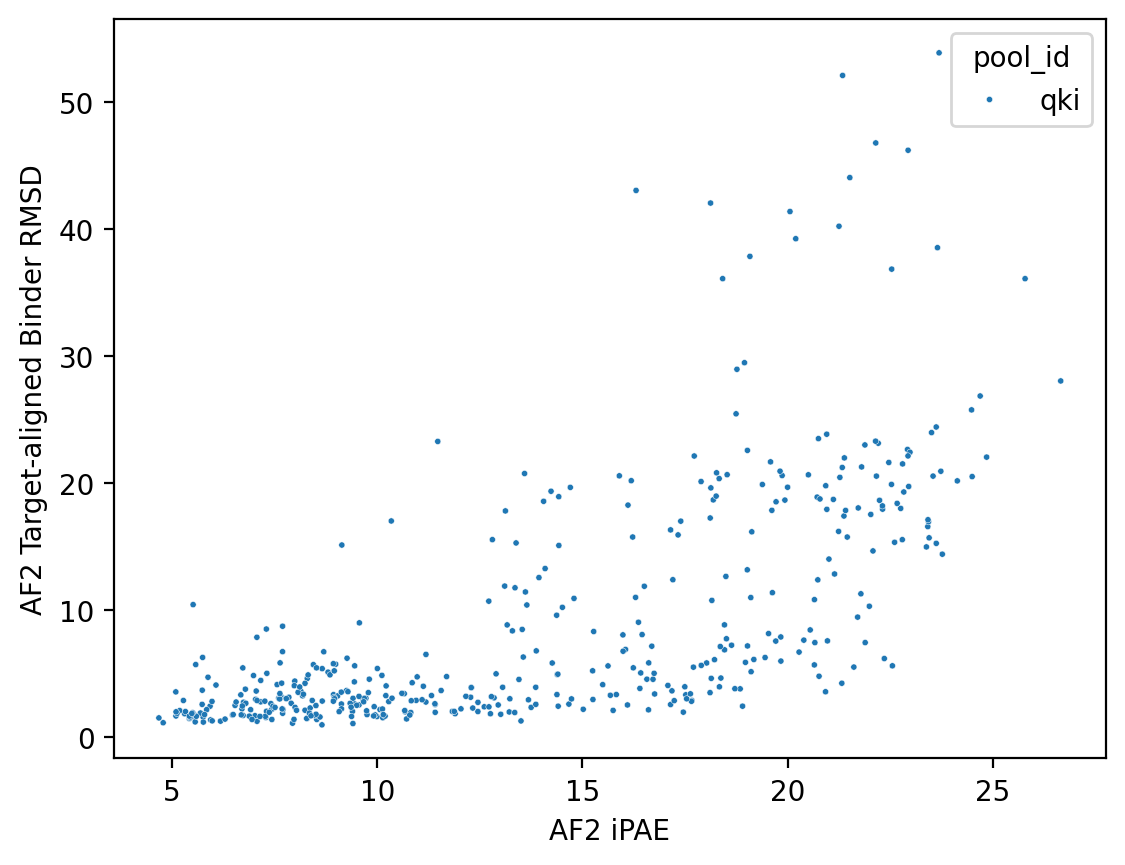

In [75]:
sns.scatterplot(designs, y='AF2 Target-aligned Binder RMSD', x='AF2 iPAE', hue='pool_id', s=5);

In [77]:
def plot_matrix(designs, thresholds):
    enabled_thresholds = [(k, t) for k, t in thresholds.items() if t.enabled]
    column_keys = [k for k, t in enabled_thresholds]
    column_descriptors = [descriptors.ALL_DESCRIPTORS_BY_KEY[k] for k in column_keys]
    column_names = [d.name for d in column_descriptors]
    g = sns.pairplot(designs[column_names + ['pool_id']], hue='pool_id', plot_kws=dict(s=5), diag_kind='hist');
    for i, (yd, (_, yt)) in enumerate(zip(column_descriptors, enabled_thresholds)):
        for j, (xd, (_, xt)) in enumerate(zip(column_descriptors, enabled_thresholds)):
            xbounds = xt.get_bounds(xd, designs[xd.name])
            ybounds = yt.get_bounds(yd, designs[yd.name])
            ax = g.axes[i][j]
            if i == j:
                ax.axvspan(*xbounds, alpha=0.2, color='#00ff00')
                continue
            assert ax.get_xlabel() == xd.name, f"{ax.get_xlabel()} != {xd.name}"
            assert ax.get_ylabel() == yd.name, f"{ax.get_ylabel()} != {yd.name}"
            ax.add_patch(plt.Rectangle((xbounds[0], ybounds[0]), xbounds[1]-xbounds[0], ybounds[1]-ybounds[0], alpha=0.2, color='#00ff00'))

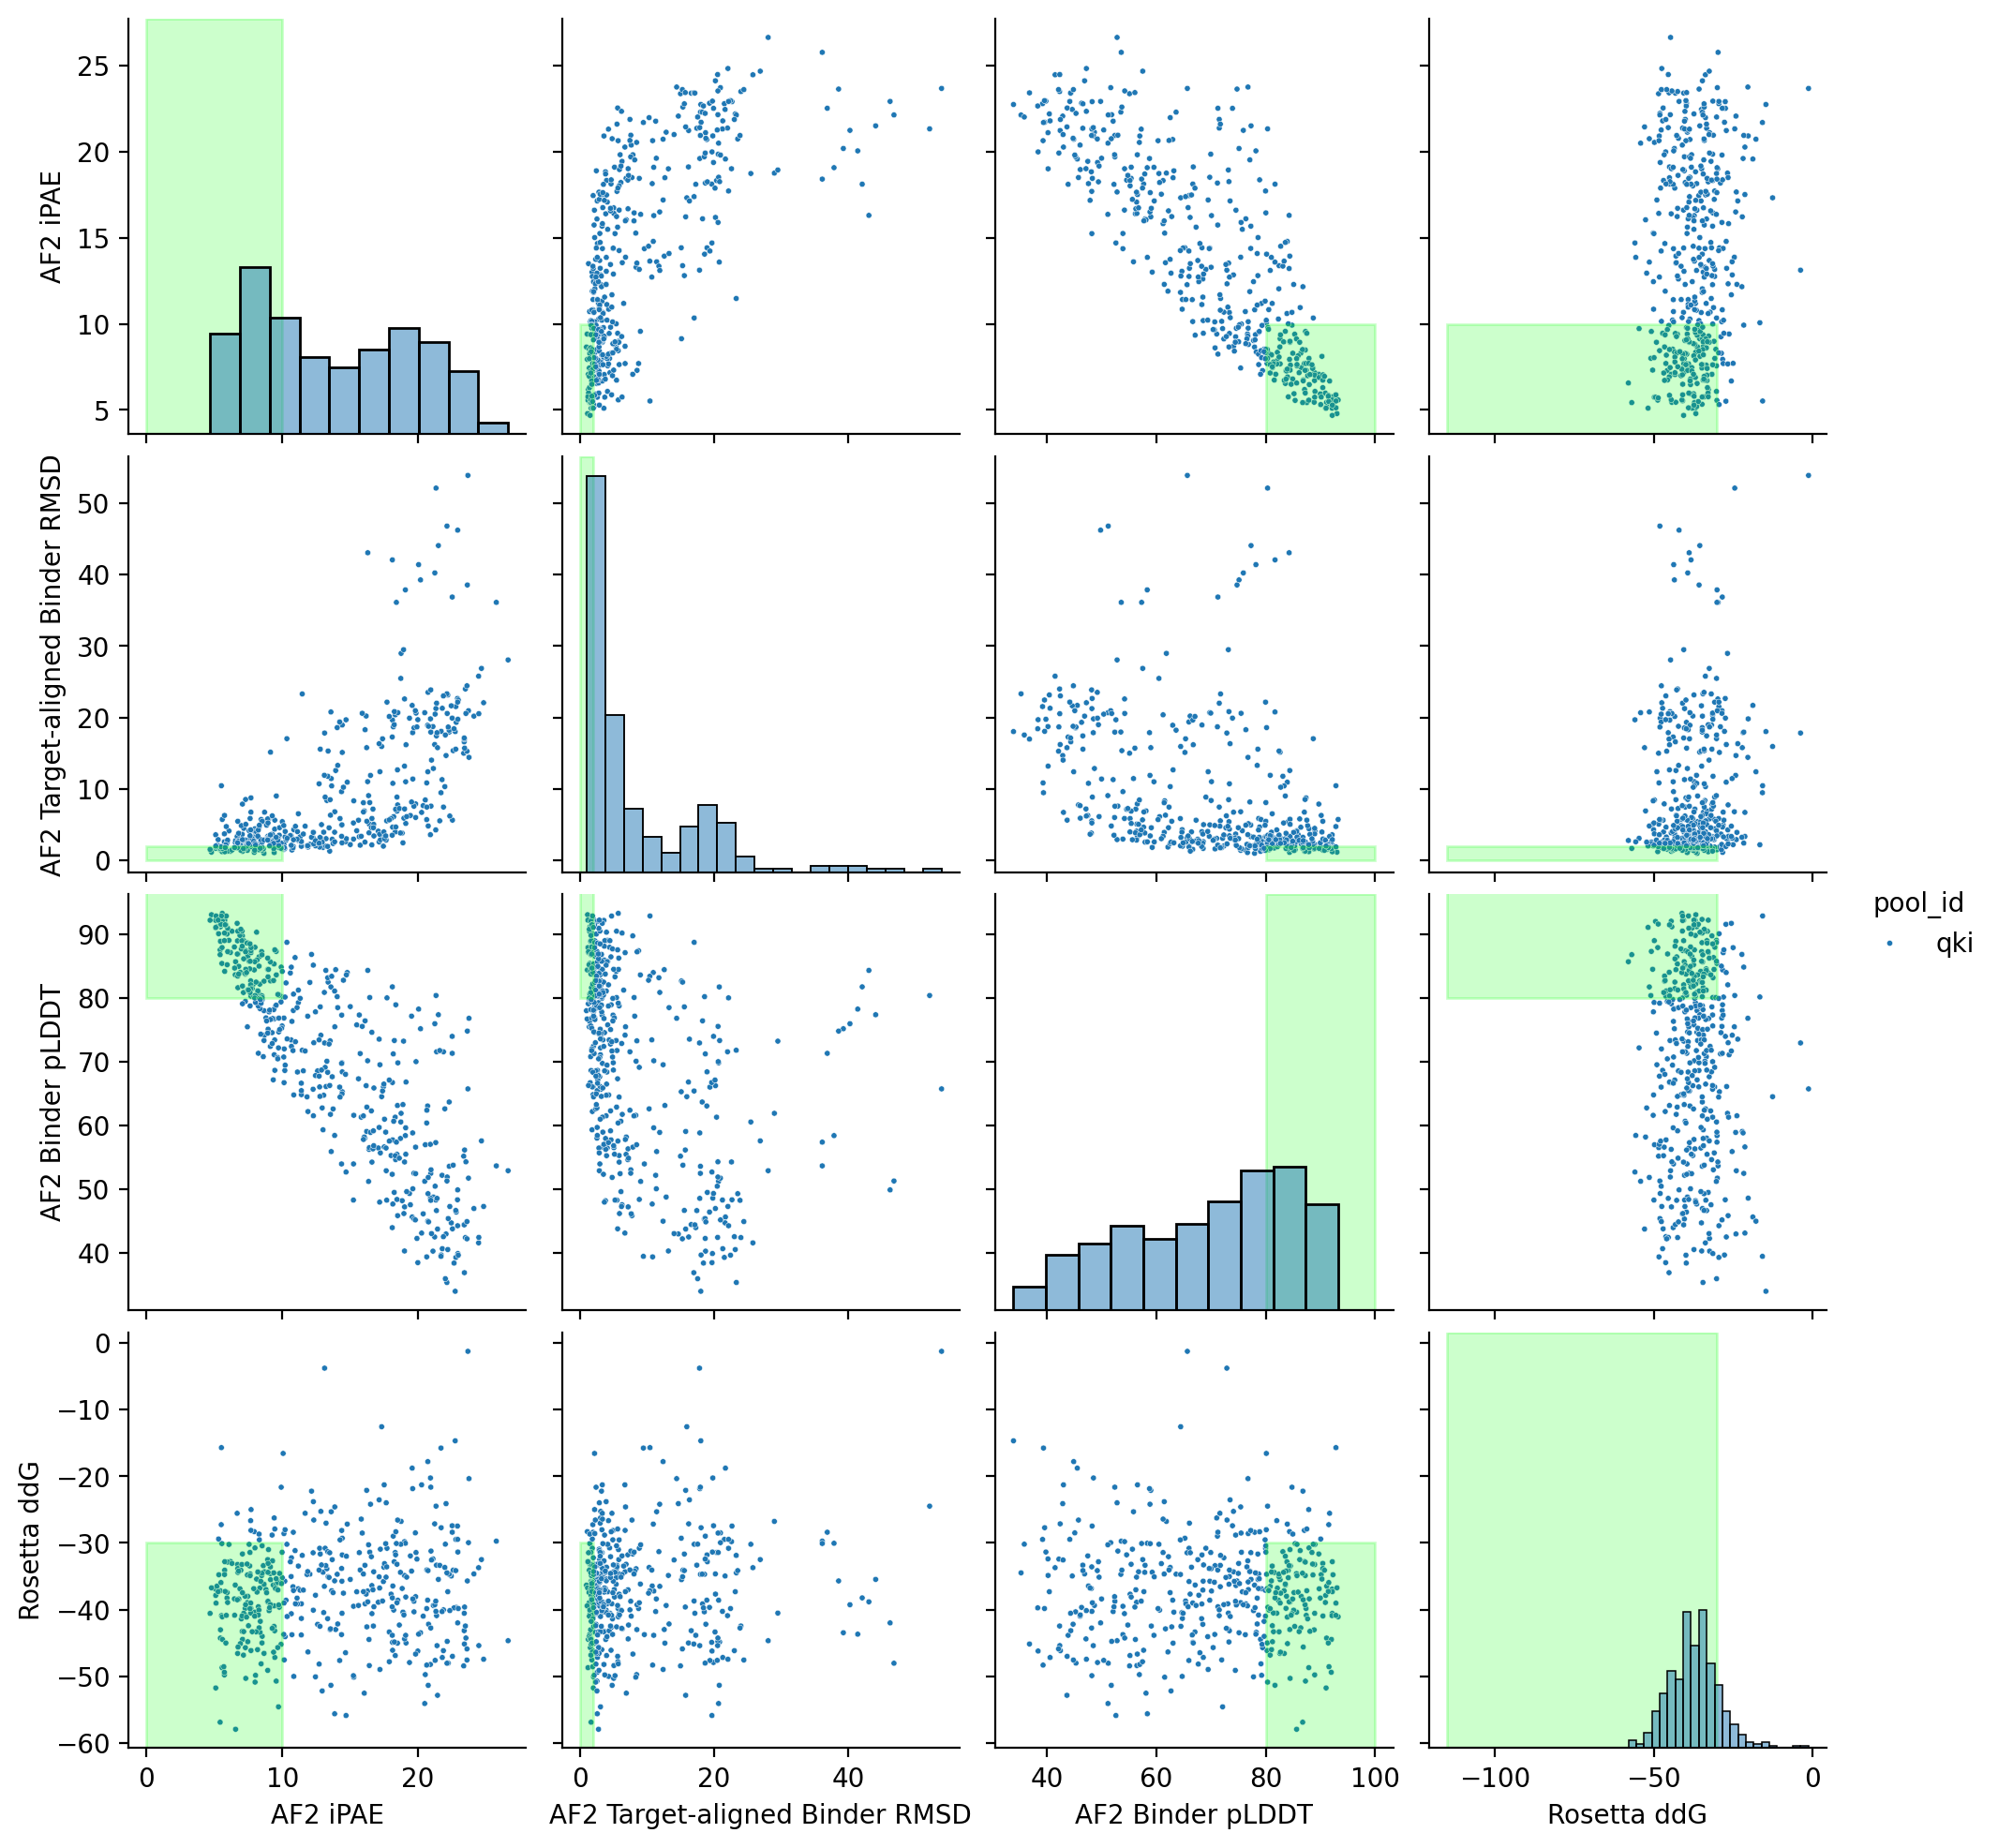

In [78]:
plot_matrix(designs, thresholds)

## Change acceptance thresholds

In [79]:
design_logic.update_acceptance_thresholds(pools=[pool], acceptance_thresholds=thresholds)

In [80]:
db.Design.count(accepted=True, pool_id=pool.id)

37

In [82]:
designs = db.Design.select(accepted=True, pool_id=pool.id)

In [85]:
print('num accepted grouped by input:')
contig_indexes = [d.contig_index for d in designs]
inputs = [workflow.rfdiffusion_params.input_pdb_paths[i] for i in contig_indexes]

pd.Series(inputs).value_counts()

num accepted grouped by input:


project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/pools/avz/designs/protein_mpnn/ovo_avz_0030_cycle02.pdb    17
project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/pools/avz/designs/protein_mpnn/ovo_avz_0124_cycle04.pdb    13
project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/pools/mmo/designs/protein_mpnn/ovo_mmo_0951_cycle02.pdb     7
Name: count, dtype: int64